In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

df = pd.read_csv(PROJECT_ROOT / "data/raw/hvac_training_dataset.csv")

print(f"shape: {df.shape}\n")
print(f"null values: {df.isnull().sum()}")

shape: (20000, 14)

null values: building_type       404
climate_zone        413
budget_level        409
area_sqft           405
floors              434
ceiling_height      374
occupancy           383
operating_hours     396
building_age        380
outdoor_temp        386
humidity            395
insulation          396
glass_ratio         452
recommended_hvac      0
dtype: int64


In [2]:
df["room_volume"] = (df["area_sqft"] * df["ceiling_height"])

df["occupancy_density"] = (df["occupancy"] / df["area_sqft"])

df["area_per_floor"] = (df["area_sqft"] / df["floors"])

df["cooling_intensity"] = (df["occupancy"] * df["operating_hours"]) / df["area_sqft"]

df[[
    "room_volume",
    "occupancy_density",
    "area_per_floor",
    "cooling_intensity"
]].describe()

,room_volume,occupancy_density,area_per_floor,cooling_intensity
count,1.922700e+04,19221.000000,19173.000000,18848.000000
mean,5.442261e+05,0.060713,13431.446199,0.796488
std,7.887196e+05,0.042156,13569.396899,0.700638
min,4.005000e+03,0.003398,125.000000,0.036672
25%,1.865958e+04,0.021095,1871.810000,0.202378
50%,2.358141e+05,0.055035,11080.290000,0.648034
75%,7.162730e+05,0.092499,20750.090000,1.130624
max,6.507405e+06,0.214453,102023.350000,4.456537


In [3]:
numerical_cols = [
    "area_sqft",
    "floors",
    "ceiling_height",
    "occupancy",
    "operating_hours",
    "building_age",
    "outdoor_temp",
    "humidity",
    "room_volume",
    "occupancy_density",
    "area_per_floor",
    "cooling_intensity"
]

categorical_cols = [
    "building_type",
    "climate_zone",
    "budget_level",
    "insulation",
    "glass_ratio"
]

In [4]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

cat_imputer = SimpleImputer(strategy="most_frequent")

df[numerical_cols] = num_imputer.fit_transform(
    df[numerical_cols]
)

df[categorical_cols] = cat_imputer.fit_transform(
    df[categorical_cols]
)

skewed_cols = [
    "area_sqft",
    "occupancy",
    "room_volume",
    "area_per_floor"
]

for col in skewed_cols:

    df[col] = np.log1p(df[col])

In [5]:
budget_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["budget_level"] = (
    df["budget_level"]
    .map(budget_map)
)

insulation_map = {
    "Poor": 0,
    "Average": 1,
    "Good": 2,
    "Excellent": 3
}

df["insulation"] = (
    df["insulation"]
    .map(insulation_map)
)

glass_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["glass_ratio"] = (
    df["glass_ratio"]
    .map(glass_map)
)

df = pd.get_dummies(
    df,
    columns=[
        "building_type",
        "climate_zone"
    ],
    drop_first=True
)

In [6]:
X = df.drop(columns=["recommended_hvac"])

y = df["recommended_hvac"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.66725
                 precision    recall  f1-score   support

Central Chiller       0.74      0.68      0.71       611
    Multi-Split       0.69      0.50      0.58       649
  Packaged Unit       0.55      0.57      0.56       772
       Split AC       0.78      0.89      0.83      1191
            VRF       0.52      0.55      0.53       777

       accuracy                           0.67      4000
      macro avg       0.66      0.64      0.64      4000
   weighted avg       0.67      0.67      0.66      4000



In [9]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance.head(15))

                      feature  importance
1                   area_sqft    0.188858
11                room_volume    0.119395
4                   occupancy    0.110843
13             area_per_floor    0.101702
14          cooling_intensity    0.062720
3              ceiling_height    0.062716
12          occupancy_density    0.056488
5             operating_hours    0.055938
17  building_type_Residential    0.033115
8                    humidity    0.031888
7                outdoor_temp    0.031767
6                building_age    0.028913
2                      floors    0.025509
16       building_type_Office    0.021113
0                budget_level    0.018534


In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [11]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

In [12]:
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.66825
              precision    recall  f1-score   support

           0       0.74      0.68      0.71       611
           1       0.66      0.50      0.57       649
           2       0.56      0.56      0.56       772
           3       0.78      0.89      0.83      1191
           4       0.53      0.57      0.55       777

    accuracy                           0.67      4000
   macro avg       0.66      0.64      0.64      4000
weighted avg       0.67      0.67      0.66      4000



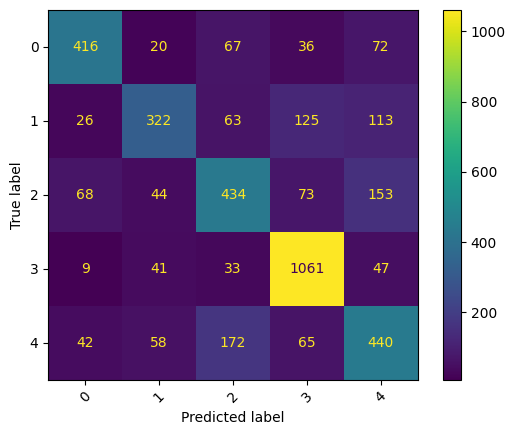

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)